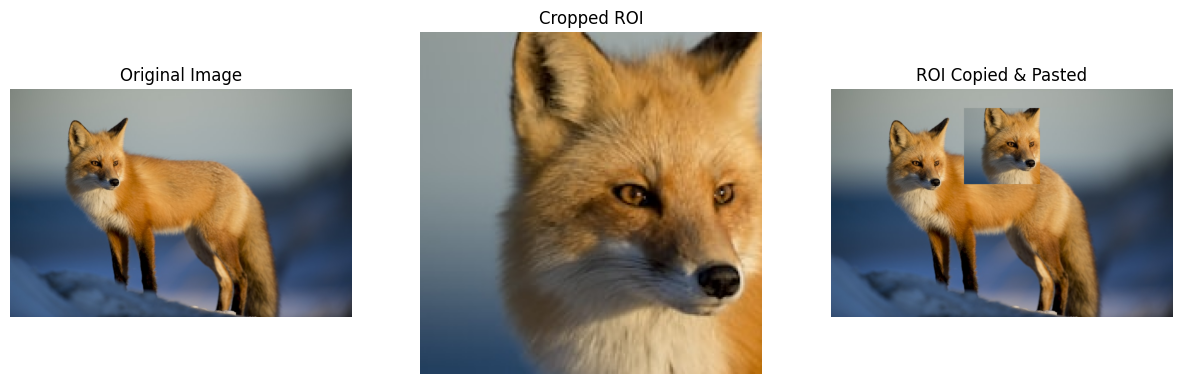

In [2]:
import cv2
from matplotlib import pyplot as plt
import urllib.request
import urllib.error # Import urllib.error to catch HTTPError

# -------------------------------
# 1. Download sample image
# -------------------------------
image_url = "https://images.unsplash.com/photo-1474511320723-9a56873867b5?auto=format&fit=crop&w=900&q=80"

# Add User-Agent header to mimic a browser, which can help with 403 Forbidden errors
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
req = urllib.request.Request(image_url, headers=headers)

try:
    with urllib.request.urlopen(req) as url_response:
        with open("sample.jpg", "wb") as file:
            file.write(url_response.read())
except urllib.error.HTTPError as e:
    print(f"Error downloading image: {e}")
    print("Please try a different image URL or check the URL permissions.")
    exit()

# -------------------------------
# 2. Read image
# -------------------------------
img = cv2.imread("sample.jpg")

if img is None:
    print("Error loading image")
    exit()

# Convert image to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------------
# 3. Select ROI (Crop Image)
# -------------------------------
# Format: img[y1:y2, x1:x2]

roi = img[100:300, 100:300]

# -------------------------------
# 4. Copy and Paste ROI
# -------------------------------
# Paste ROI into another region

img[50:250, 350:550] = roi

# Convert final image to RGB
result_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert ROI to RGB
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

# -------------------------------
# 5. Display images
# -------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Cropped ROI")
plt.imshow(roi_rgb)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("ROI Copied & Pasted")
plt.imshow(result_rgb)
plt.axis('off')

plt.show()